### Question:

When I used the trained model, it generates <br>
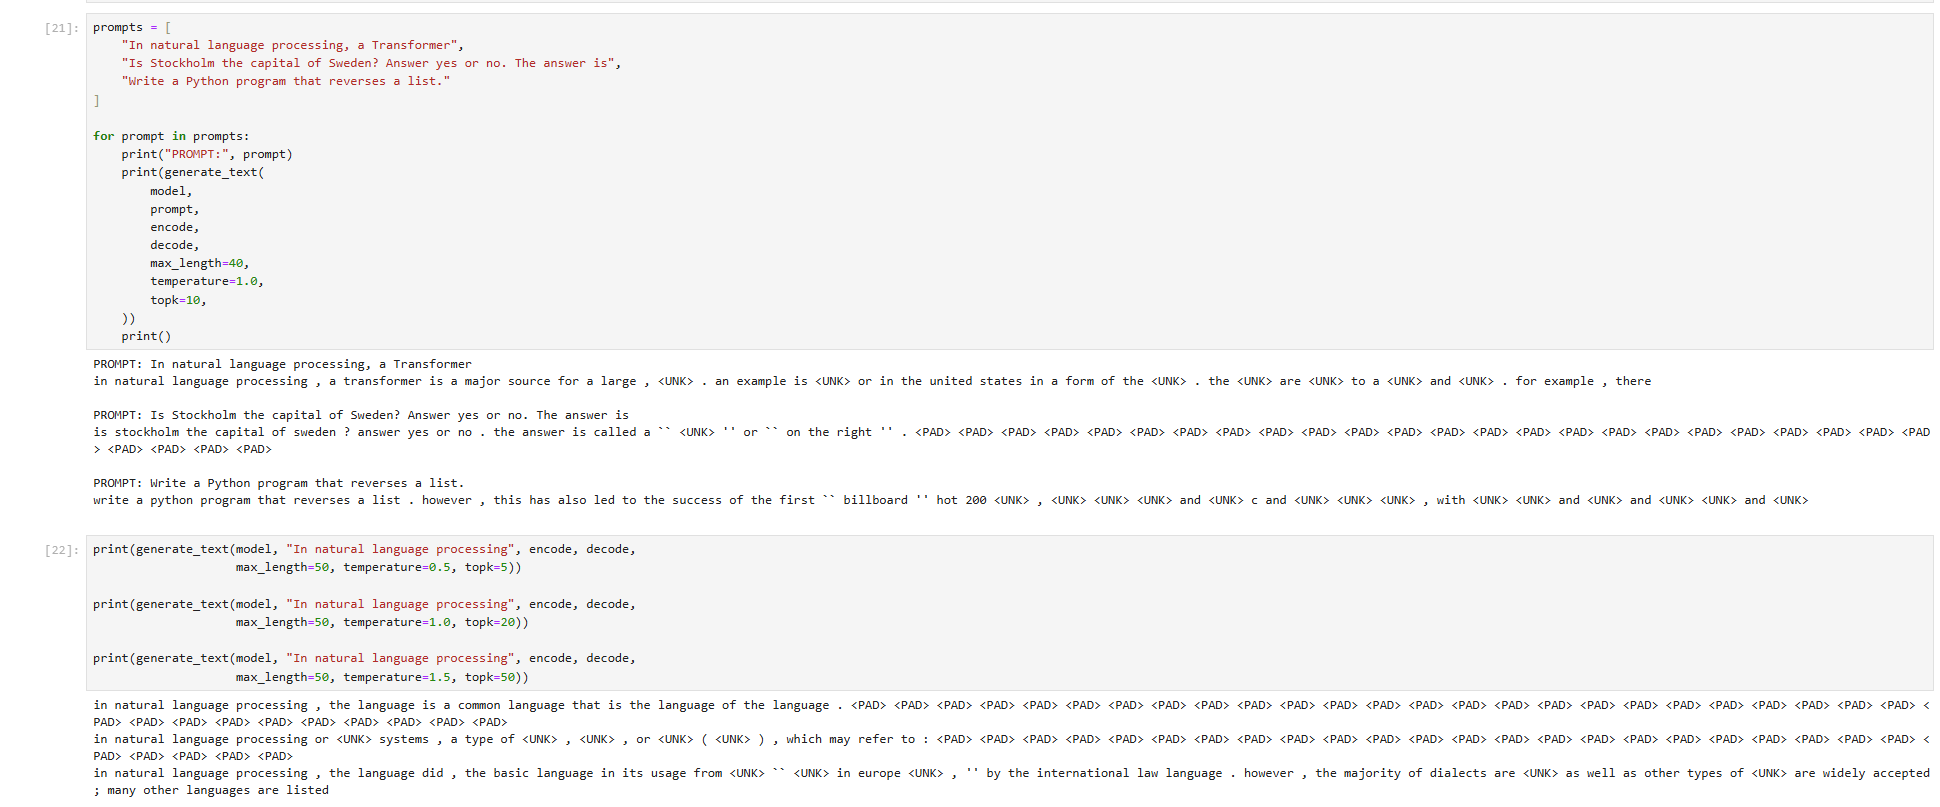

but if I compared it with pre-trained model, it returns <br>
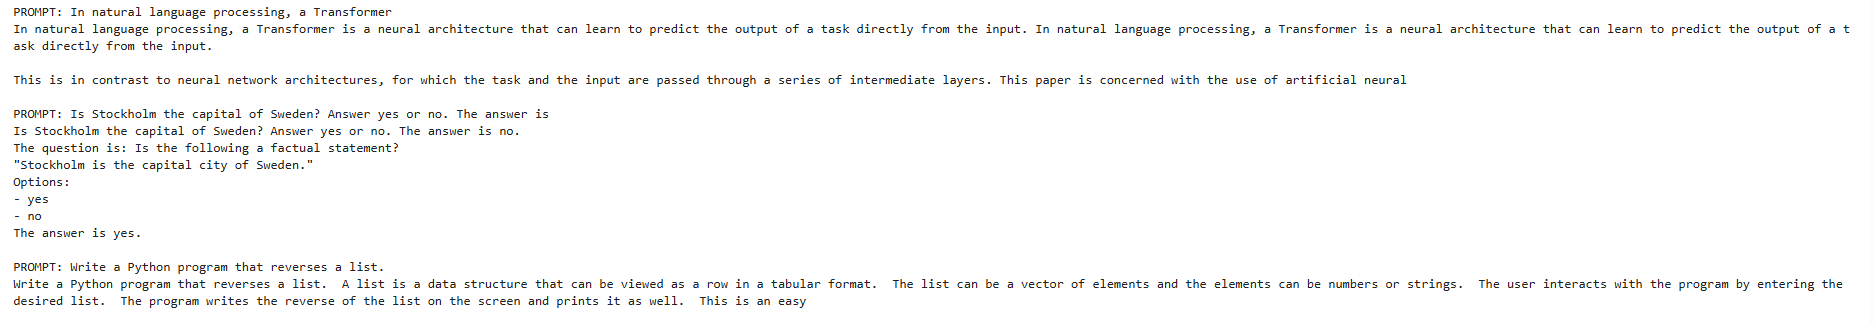

I already set max_voc_size=30000 in tokenizer, I'm wondering why there are still some words missing. Thanks!

### Step 1: Setting up a Transformer neural network

#### Configuration

In [1]:
import torch, nltk, pickle
from torch import nn
from collections import Counter
from transformers import BatchEncoding, PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput

from torch.utils.data import DataLoader
import numpy as np
import sys, time, os


In [2]:
class A2ModelConfig(PretrainedConfig):
    """Configuration object that stores hyperparameters that define the Transformer language model."""
    def __init__(self, vocab_size=None, hidden_size=None, intermediate_size=None, num_attention_heads=None, 
                 num_hidden_layers=None,
                 rope_theta=None, hidden_act='silu', max_position_embeddings=None, rms_norm_eps=None, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.max_position_embeddings = max_position_embeddings
        self.rms_norm_eps = rms_norm_eps
        self.num_attention_heads = num_attention_heads
        self.rope_theta = rope_theta
        self.hidden_act = hidden_act
        self.intermediate_size = intermediate_size
        self.num_hidden_layers = num_hidden_layers

#### Task 1.1: MLP layer

In [3]:
class A2MLP(nn.Module):
    """The MLP layer of the Transformer. Uses the SwiGLU architecture."""
    def __init__(self, config):
        super().__init__()
        assert(config.hidden_act == 'silu')
        # TODO: initalize components here
        self.gate_proj = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.up_proj   = nn.Linear(config.hidden_size, config.intermediate_size, bias=False)
        self.down_proj = nn.Linear(config.intermediate_size, config.hidden_size, bias=False)

        self.act_fn = nn.SiLU()


    def forward(self, hidden_states):
        gate = self.act_fn(self.gate_proj(hidden_states))  
        up   = self.up_proj(hidden_states)                 
        return self.down_proj(gate * up)               

In [4]:
config = A2ModelConfig(
    hidden_size=512,
    intermediate_size=2048,
    hidden_act='silu',
)

mlp = A2MLP(config)

# Arbitrary 3-D tensor: (batch=2, seq_len=10, hidden_size=64)
x = torch.randn(2, 10, config.hidden_size)
y = mlp(x)

print(f"Input shape:  {x.shape}")   # torch.Size([2, 10, 512])
print(f"Output shape: {y.shape}")   # torch.Size([2, 10, 512])

Input shape:  torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])


####  Task 1.2: Normalization 

In [5]:
class A2RMSNorm(nn.Module):
    """RMS layer normalization."""

    def __init__(self, config):
        super().__init__()

        self.eps = config.rms_norm_eps

        self.weight = nn.Parameter(
            torch.ones(config.hidden_size)
        )

    def forward(self, hidden_states):

        # [B,T,H]
        variance = hidden_states.pow(2).mean(dim=-1, keepdim=True)

        rms = torch.sqrt(variance + self.eps)

        normalized = hidden_states / rms

        output = normalized * self.weight

        return output

In [6]:
x = torch.randn(2, 10, 512)
config.rms_norm_eps = 1e-6
norm = A2RMSNorm(config)

y = norm(x)

print(x.shape)
print(y.shape)

torch.Size([2, 10, 512])
torch.Size([2, 10, 512])


#### Task 1.3: Multi-head attention

In [7]:
import math
import torch.nn.functional as F

class A2Attention(nn.Module):
    """The multi-head attention layer of the Transformer."""

    def __init__(self, config):
        super().__init__()

        assert config.hidden_size % config.num_attention_heads == 0

        self.hidden_size = config.hidden_size
        self.num_attention_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads

        self.q_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.k_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.v_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)
        self.o_proj = nn.Linear(config.hidden_size, config.hidden_size, bias=False)

        self.q_norm = A2RMSNorm(config)
        self.k_norm = A2RMSNorm(config)

    def forward(self, hidden_states, rope_rotations):
        b, m, d = hidden_states.shape
        n_h = self.num_attention_heads
        d_h = self.head_dim

        q = self.q_proj(hidden_states)
        k = self.k_proj(hidden_states)
        v = self.v_proj(hidden_states)

        q = self.q_norm(q)
        k = self.k_norm(k)

        q = q.view(b, m, n_h, d_h).transpose(1, 2)
        k = k.view(b, m, n_h, d_h).transpose(1, 2)
        v = v.view(b, m, n_h, d_h).transpose(1, 2)

        q, k = apply_rotary_pos_emb(q, k, rope_rotations)

        attn_out = F.scaled_dot_product_attention(
            q,
            k,
            v,
            is_causal=True
        )

        attn_out = attn_out.transpose(1, 2).reshape(b, m, d)

        output = self.o_proj(attn_out)

        return output

In [8]:
#### RoPE implementation (copied and simplified from HuggingFace). ####

def apply_rotary_pos_emb(q, k, rope_rotations, unsqueeze_dim=1):
    """Applies precomputed RoPE rotations to the query and key representations."""
    assert(q.shape == k.shape)
    assert(len(q.shape) == 4)
    cos, sin = rope_rotations
    assert(q.shape[2] == cos.shape[1])
    assert(q.shape[3] == cos.shape[2])    
    q_type, k_type = q.dtype, k.dtype
    cos = cos.unsqueeze(unsqueeze_dim)
    sin = sin.unsqueeze(unsqueeze_dim)
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed.to(q_type), k_embed.to(k_type)

def rotate_half(x):
    """Rotates half the hidden dims of the input."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)

class A2RotaryEmbedding(nn.Module):
    """RoPE position representation for use in Transformer attention."""

    def __init__(self, config, device=None):
        super().__init__()
        rope_theta = config.rope_theta
        head_dim = config.hidden_size // config.num_attention_heads
        partial_rotary_factor = 1.0
        dim = int(head_dim * partial_rotary_factor)
        self.inv_freq = 1.0 / (rope_theta ** (torch.arange(0, dim, 2, dtype=torch.int64).to(device=device, dtype=torch.float) / dim))

    @torch.no_grad()
    def forward(self, x):
        position_ids = torch.arange(0, x.shape[1], device=x.device).unsqueeze(0)
        inv_freq_expanded = self.inv_freq[None, :, None].float().expand(position_ids.shape[0], -1, 1).to(x.device)
        position_ids_expanded = position_ids[:, None, :].float()

        device_type = x.device.type if isinstance(x.device.type, str) and x.device.type != "mps" else "cpu"
        with torch.autocast(device_type=device_type, enabled=False):  # Force float32
            freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
            emb = torch.cat((freqs, freqs), dim=-1)
            cos = emb.cos()
            sin = emb.sin()
            return cos, sin

In [9]:
config.rope_theta = 10000
config.num_attention_heads = 8
config.rms_norm_eps = 1e-6

x = torch.randn(2, 10, config.hidden_size)

attn = A2Attention(config)
rope = A2RotaryEmbedding(config)

rope_rotations = rope(x)

y = attn(x, rope_rotations)

print(x.shape)
print(y.shape)

torch.Size([2, 10, 512])
torch.Size([2, 10, 512])


#### Task 1.4: The full Transformer decoder layer

In [10]:
class A2DecoderLayer(nn.Module):
    """A complete Transformer decoder layer."""

    def __init__(self, config):
        super().__init__()

        self.self_attn = A2Attention(config)
        self.mlp = A2MLP(config)

        self.attn_norm = A2RMSNorm(config)
        self.mlp_norm = A2RMSNorm(config)

    def forward(self, hidden_states, rope_rotations):
        # Attention block
        residual = hidden_states

        hidden_states = self.self_attn(hidden_states, rope_rotations)
        hidden_states = self.attn_norm(hidden_states)
        hidden_states = hidden_states + residual

        residual = hidden_states

        hidden_states = self.mlp(hidden_states)
        hidden_states = self.mlp_norm(hidden_states)
        hidden_states = hidden_states + residual

        return hidden_states

In [11]:
config.hidden_size = 512
config.intermediate_size = 2048
config.num_attention_heads = 8
config.hidden_act = "silu"
config.rms_norm_eps = 1e-6
config.rope_theta = 10000

x = torch.randn(2, 10, config.hidden_size)

layer = A2DecoderLayer(config)
rope = A2RotaryEmbedding(config)
rope_rotations = rope(x)

y = layer(x, rope_rotations)

print(x.shape)
print(y.shape)

torch.Size([2, 10, 512])
torch.Size([2, 10, 512])


#### Task 1.5: The complete Transformer stack

In [12]:
from transformers import PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput
import torch
import torch.nn as nn

class A2Transformer(PreTrainedModel):
    """A language model based on the Transformer architecture."""
    
    config_class = A2ModelConfig

    def __init__(self, config):
        super().__init__(config)

        self.rotary_emb = A2RotaryEmbedding(config)

        self.embedding = nn.Embedding(
            num_embeddings=config.vocab_size,
            embedding_dim=config.hidden_size
        )

        self.layers = nn.ModuleList([
            A2DecoderLayer(config)
            for _ in range(config.num_hidden_layers)
        ])

        self.norm = A2RMSNorm(config)

        self.unembedding = nn.Linear(
            config.hidden_size,
            config.vocab_size,
            bias=False
        )

        self.loss_func = nn.CrossEntropyLoss(ignore_index=-100)

        self.post_init()

    def forward(self, input_ids, labels=None):
        rope_rotations = self.rotary_emb(input_ids)

        hidden_states = self.embedding(input_ids)

        for layer in self.layers:
            hidden_states = layer(hidden_states, rope_rotations)

        hidden_states = self.norm(hidden_states)

        logits = self.unembedding(hidden_states)

        loss = None

        if labels is not None:
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            shift_logits = shift_logits.view(-1, shift_logits.shape[-1])
            shift_labels = shift_labels.view(-1)

            loss = self.loss_func(shift_logits, shift_labels)

        return CausalLMOutput(
            loss=loss,
            logits=logits
        )

In [13]:
config.vocab_size = 10000
config.hidden_size = 512
config.intermediate_size = 2048
config.num_attention_heads = 8
config.num_hidden_layers = 4
config.hidden_act = "silu"
config.rms_norm_eps = 1e-6
config.rope_theta = 10000

model = A2Transformer(config)

input_ids = torch.randint(0, config.vocab_size, (2, 10))

out = model(input_ids)

print(out.logits.shape)

torch.Size([2, 10, 10000])


### Step 2: Training the language model

In [15]:
def lowercase_tokenizer(text):
    return [t.lower() for t in nltk.word_tokenize(text)]

def build_tokenizer(train_file, tokenize_fun=lowercase_tokenizer, max_voc_size=None, model_max_length=None,
                    pad_token='<PAD>', unk_token='<UNK>', bos_token='<BOS>', eos_token='<EOS>'):
    """ Build a tokenizer from the given file.

        Args:
             train_file:        The name of the file containing the training texts.
             tokenize_fun:      The function that maps a text to a list of string tokens.
             max_voc_size:      The maximally allowed size of the vocabulary.
             model_max_length:  Truncate texts longer than this length.
             pad_token:         The dummy string corresponding to padding.
             unk_token:         The dummy string corresponding to out-of-vocabulary tokens.
             bos_token:         The dummy string corresponding to the beginning of the text.
             eos_token:         The dummy string corresponding to the end the text.
    """

    # TODO: build the vocabulary, possibly truncating it to max_voc_size if that is specified.
    # Then return a tokenizer object (implemented below).
    counter = Counter()
    with open(train_file, 'r', encoding="utf-8") as f:
        for line in f:
            tokens = tokenize_fun(line)
            counter.update(tokens)

    special_tokens = [pad_token, unk_token, bos_token, eos_token]

    if max_voc_size is not None:
        most_common = counter.most_common(max_voc_size - len(special_tokens))
        common_tokens = [token for token, _ in most_common]
    else:
        common_tokens =  [token for token, _ in counter.most_common()]

    vocab = {token: i for i, token in enumerate(special_tokens + common_tokens)}

    return A1Tokenizer(
        vocab=vocab,
        tokenize_fun=tokenize_fun,
        model_max_length=model_max_length,
        pad_token=pad_token,
        unk_token=unk_token,
        bos_token=bos_token,
        eos_token=eos_token
    )


class A1Tokenizer:
    """A minimal implementation of a tokenizer similar to tokenizers in the HuggingFace library."""

    def __init__(self, vocab, tokenize_fun, model_max_length, pad_token='<PAD>', unk_token='<UNK>',
                 bos_token='<BOS>', eos_token='<EOS>'):
        # TODO: store all values you need in order to implement __call__ below.
        #self.pad_token_id = ...     # Compulsory attribute.
        #self.model_max_length = ... # Needed for truncation.
        self.vocab = vocab
        self.tokenize_fun = tokenize_fun
        self.model_max_length = model_max_length

        self.token2id = vocab                                       # str -> int
        self.id2token = {i: token for token, i in vocab.items()}   # int -> str

        self.pad_token = pad_token
        self.unk_token = unk_token
        self.bos_token = bos_token
        self.eos_token = eos_token

        self.pad_token_id = vocab[pad_token]  
        self.unk_token_id = vocab[unk_token]   
        self.bos_token_id = vocab[bos_token]
        self.eos_token_id = vocab[eos_token]

    def __call__(self, texts, truncation=False, padding=False, return_tensors=None):
        """Tokenize the given texts and return a BatchEncoding containing the integer-encoded tokens.
           
           Args:
             texts:           The texts to tokenize.
             truncation:      Whether the texts should be truncated to model_max_length.
             padding:         Whether the tokenized texts should be padded on the right side.
             return_tensors:  If None, then return lists; if 'pt', then return PyTorch tensors.

           Returns:
             A BatchEncoding where the field `input_ids` stores the integer-encoded texts.
        """
        if return_tensors and return_tensors != 'pt':
            raise ValueError('Should be pt')
        
        # TODO: Your work here is to split the texts into words and map them to integer values.
        # 
        # - If `truncation` is set to True, the length of the encoded sequences should be 
        #   at most self.model_max_length.
        # - If `padding` is set to True, then all the integer-encoded sequences should be of the
        #   same length. That is: the shorter sequences should be "padded" by adding dummy padding
        #   tokens on the right side.
        # - If `return_tensors` is undefined, then the returned `input_ids` should be a list of lists.
        #   Otherwise, if `return_tensors` is 'pt', then `input_ids` should be a PyTorch 2D tensor.
        if isinstance(texts, str):
            texts = [texts]

        encoded_texts = []

        for text in texts:
            tokens = self.tokenize_fun(text)
            ids = [self.token2id.get(tok, self.unk_token_id) for tok in tokens]

            if truncation:
                ids = ids[:self.model_max_length]

            encoded_texts.append(ids)

            attention_mask = None


        if padding:
            max_len = max(len(ids) for ids in encoded_texts)

            if truncation:
                max_len = min(max_len, self.model_max_length)

            padded_texts = []
            attention_mask = []

            for ids in encoded_texts:
                if truncation:
                    ids = ids[:max_len]
                
                padding_length = max_len - len(ids)
                padded_ids = ids + [self.pad_token_id] * padding_length
                mask = [1] * len(ids) + [0] * padding_length

                padded_texts.append(padded_ids)
                attention_mask.append(mask)
        
            encoded_texts = padded_texts

        else:
            attention_mask = [[1] * len(ids) for ids in encoded_texts]

        if return_tensors == 'pt':
            input_ids = torch.tensor(encoded_texts, dtype=torch.long)
            attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        else:
            input_ids = encoded_texts
        
        
        # TODO: Return a BatchEncoding where input_ids stores the result of the integer encoding.
        # Optionally, if you want to be 100% HuggingFace-compatible, you should also include an 
        # attention mask of the same shape as input_ids. In this mask, padding tokens correspond
        # to the the value 0 and real tokens to the value 1.
        return BatchEncoding({'input_ids': input_ids, 'attention_mask': attention_mask})

    def __len__(self):
        """Return the size of the vocabulary."""
        return len(self.vocab)
    
    def save(self, filename):
        """Save the tokenizer to the given file."""
        with open(filename, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def from_file(filename):
        """Load a tokenizer from the given file."""
        with open(filename, 'rb') as f:
            return pickle.load(f)


tokenizer = build_tokenizer("train.txt", max_voc_size=30000, model_max_length=256,)

In [16]:
import math
import torch
from transformers import Trainer, TrainingArguments
from datasets import Dataset
from transformers import DataCollatorForLanguageModeling

current_path = os.getcwd()
train_path = os.path.join(current_path, "train.txt")
val_path = os.path.join(current_path, "val.txt")

with open(train_path, "r", encoding="utf-8") as f:
    train_dataset = [line.strip() for line in f if line.strip()]

with open(val_path, "r", encoding="utf-8") as f:
    val_dataset = [line.strip() for line in f if line.strip()]



if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


train_encodings = tokenizer(train_dataset, padding=True, truncation=True,)

val_encodings = tokenizer(val_dataset, padding=True, truncation=True,
)

train_encodings["labels"] = train_encodings["input_ids"].copy()
val_encodings["labels"] = val_encodings["input_ids"].copy()

train_dataset = Dataset.from_dict(train_encodings)
val_dataset = Dataset.from_dict(val_encodings)

train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")



config = A2ModelConfig(
    vocab_size=len(tokenizer),
    hidden_size=256,
    num_hidden_layers=2,
    num_attention_heads=4,
    intermediate_size=1024,
    max_position_embeddings=512,
    rope_theta=10000,
    rms_norm_eps=1e-6,
)

model = A2Transformer(config)

training_args = TrainingArguments(
    output_dir="./a2_transformer_lm",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-4,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    fp16=torch.cuda.is_available(),
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

eval_logs = [x for x in trainer.state.log_history if "eval_loss" in x]
last_eval_loss = eval_logs[-1]["eval_loss"]

perplexity = math.exp(last_eval_loss)

print("Validation loss:", last_eval_loss)
print("Validation perplexity:", perplexity)

[RANK 0] Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


{'loss': '5.315', 'grad_norm': '6.129', 'learning_rate': '0.0002984', 'epoch': '0.00544'}
{'loss': '2.294', 'grad_norm': '0.3898', 'learning_rate': '0.0002968', 'epoch': '0.01088'}
{'loss': '2.031', 'grad_norm': '0.2981', 'learning_rate': '0.0002951', 'epoch': '0.01632'}
{'loss': '2.125', 'grad_norm': '0.3974', 'learning_rate': '0.0002935', 'epoch': '0.02176'}
{'loss': '2.031', 'grad_norm': '0.3728', 'learning_rate': '0.0002919', 'epoch': '0.0272'}
{'loss': '1.98', 'grad_norm': '0.3022', 'learning_rate': '0.0002902', 'epoch': '0.03264'}
{'loss': '2.049', 'grad_norm': '0.4408', 'learning_rate': '0.0002886', 'epoch': '0.03808'}
{'loss': '1.892', 'grad_norm': '0.3888', 'learning_rate': '0.000287', 'epoch': '0.04352'}
{'loss': '1.953', 'grad_norm': '0.3143', 'learning_rate': '0.0002853', 'epoch': '0.04896'}
{'loss': '1.924', 'grad_norm': '0.3104', 'learning_rate': '0.0002837', 'epoch': '0.0544'}
{'loss': '1.855', 'grad_norm': '0.536', 'learning_rate': '0.0002821', 'epoch': '0.05983'}
{'los

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '211.8', 'train_samples_per_second': '694.5', 'train_steps_per_second': '43.41', 'train_loss': '1.625', 'epoch': '1'}
Validation loss: 1.5607481002807617
Validation perplexity: 4.762382652626311


### Step 3: Generating text

#### Task 3.1: Predicting the next word

In [17]:
import torch
from torch.distributions import Categorical

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

A2Transformer(
  (rotary_emb): A2RotaryEmbedding()
  (embedding): Embedding(30000, 256)
  (layers): ModuleList(
    (0-1): 2 x A2DecoderLayer(
      (self_attn): A2Attention(
        (q_proj): Linear(in_features=256, out_features=256, bias=False)
        (k_proj): Linear(in_features=256, out_features=256, bias=False)
        (v_proj): Linear(in_features=256, out_features=256, bias=False)
        (o_proj): Linear(in_features=256, out_features=256, bias=False)
        (q_norm): A2RMSNorm()
        (k_norm): A2RMSNorm()
      )
      (mlp): A2MLP(
        (gate_proj): Linear(in_features=256, out_features=1024, bias=False)
        (up_proj): Linear(in_features=256, out_features=1024, bias=False)
        (down_proj): Linear(in_features=1024, out_features=256, bias=False)
        (act_fn): SiLU()
      )
      (attn_norm): A2RMSNorm()
      (mlp_norm): A2RMSNorm()
    )
  )
  (norm): A2RMSNorm()
  (unembedding): Linear(in_features=256, out_features=30000, bias=False)
  (loss_func): CrossEntr

In [18]:
def predict_next_token(model, prompt, encode, decode):
    model.eval()

    input_ids = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )

    with torch.no_grad():
        outputs = model(input_ids=input_ids)
        logits = outputs.logits

    next_token_logits = logits[0, -1, :]
    next_token_id = torch.argmax(next_token_logits).item()

    return next_token_id, decode([next_token_id])

In [19]:
def encode(text):
    return tokenizer(text)["input_ids"][0]

def decode(ids):
    return " ".join(tokenizer.id2token[i] for i in ids)
    
next_id, next_word = predict_next_token(
    model,
    "he lives in san",
    encode,
    decode
)

print(next_id)
print(next_word)

2452
francisco


#### Task 3.2: Generating texts

In [20]:
def generate_text(
    model,
    prompt,
    encode,
    decode,
    max_length=50,
    temperature=1.0,
    topk=None,
    eos_token_id=None
):
    model.eval()

    generated_ids = encode(prompt)

    for _ in range(max_length):
        input_ids = torch.tensor(
            [generated_ids],
            dtype=torch.long,
            device=device
        )

        with torch.no_grad():
            outputs = model(input_ids=input_ids)
            logits = outputs.logits

        next_token_logits = logits[0, -1, :]

        # temperature scaling
        next_token_logits = next_token_logits / temperature

        # top-k sampling
        if topk is not None:
            values, indices = torch.topk(next_token_logits, topk)

            distribution = Categorical(logits=values)
            sampled_position = distribution.sample()

            next_token_id = indices[sampled_position].item()
        else:
            distribution = Categorical(logits=next_token_logits)
            next_token_id = distribution.sample().item()

        generated_ids.append(next_token_id)

        if eos_token_id is not None and next_token_id == eos_token_id:
            break

    return decode(generated_ids)

In [21]:
prompts = [
    "In natural language processing, a Transformer",
    "Is Stockholm the capital of Sweden? Answer yes or no. The answer is",
    "Write a Python program that reverses a list."
]

for prompt in prompts:
    print("PROMPT:", prompt)
    print(generate_text(
        model,
        prompt,
        encode,
        decode,
        max_length=40,
        temperature=1.0,
        topk=10,
    ))
    print()

PROMPT: In natural language processing, a Transformer
in natural language processing , a transformer is a major source for a large , <UNK> . an example is <UNK> or in the united states in a form of the <UNK> . the <UNK> are <UNK> to a <UNK> and <UNK> . for example , there

PROMPT: Is Stockholm the capital of Sweden? Answer yes or no. The answer is
is stockholm the capital of sweden ? answer yes or no . the answer is called a `` <UNK> '' or `` on the right '' . <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>

PROMPT: Write a Python program that reverses a list.
write a python program that reverses a list . however , this has also led to the success of the first `` billboard '' hot 200 <UNK> , <UNK> <UNK> <UNK> and <UNK> c and <UNK> <UNK> <UNK> , with <UNK> <UNK> and <UNK> and <UNK> <UNK> and <UNK>



In [22]:
print(generate_text(model, "In natural language processing", encode, decode,
                    max_length=50, temperature=0.5, topk=5))

print(generate_text(model, "In natural language processing", encode, decode,
                    max_length=50, temperature=1.0, topk=20))

print(generate_text(model, "In natural language processing", encode, decode,
                    max_length=50, temperature=1.5, topk=50))

in natural language processing , the language is a common language that is the language of the language . <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
in natural language processing or <UNK> systems , a type of <UNK> , <UNK> , or <UNK> ( <UNK> ) , which may refer to : <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
in natural language processing , the language did , the basic language in its usage from <UNK> `` <UNK> in europe <UNK> , '' by the international law language . however , the majority of dialects are <UNK> as well as other types of <UNK> are widely accepted ; many other languages are listed


#### Task 3.3: Comparing to a pre-trained Transformer

In [23]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from torch.distributions import Categorical

MODEL_NAME = "allenai/OLMo-2-0425-1B"
SAVE_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-515/to-arrhenius-disk/yingyi/huggingface"



hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=SAVE_PATH)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, cache_dir=SAVE_PATH).to(device)
hf_model.eval()

Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

Olmo2ForCausalLM(
  (model): Olmo2Model(
    (embed_tokens): Embedding(100352, 2048, padding_idx=100277)
    (layers): ModuleList(
      (0-15): 16 x Olmo2DecoderLayer(
        (self_attn): Olmo2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Olmo2RMSNorm((2048,), eps=1e-06)
          (k_norm): Olmo2RMSNorm((2048,), eps=1e-06)
        )
        (mlp): Olmo2MLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (post_attention_layernorm): Olmo2RMSNorm((2048,), eps=1e-06

In [24]:
def generate_text_hf(
    model,
    tokenizer,
    prompt,
    max_length=50,
    temperature=1.0,
    topk=None
):
    model.eval()

    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    generated_ids = input_ids[0].tolist()

    eos_token_id = tokenizer.eos_token_id

    for _ in range(max_length):
        current_input = torch.tensor(
            [generated_ids],
            dtype=torch.long,
            device=device
        )

        with torch.no_grad():
            outputs = model(input_ids=current_input)
            logits = outputs.logits

        next_token_logits = logits[0, -1, :] / temperature

        if topk is not None:
            values, indices = torch.topk(next_token_logits, topk)
            distr = Categorical(logits=values)
            sampled_pos = distr.sample()
            next_token_id = indices[sampled_pos].item()
        else:
            distr = Categorical(logits=next_token_logits)
            next_token_id = distr.sample().item()

        generated_ids.append(next_token_id)

        if eos_token_id is not None and next_token_id == eos_token_id:
            break

    return tokenizer.decode(generated_ids, skip_special_tokens=True)

In [25]:
for prompt in prompts:
    print("PROMPT:", prompt)
    print(generate_text_hf(
        hf_model,
        hf_tokenizer,
        prompt,
        max_length=80,
        temperature=0.8,
        topk=40
    ))
    print()

PROMPT: In natural language processing, a Transformer
In natural language processing, a Transformer is a neural architecture that can learn to predict the output of a task directly from the input. In natural language processing, a Transformer is a neural architecture that can learn to predict the output of a task directly from the input.

This is in contrast to neural network architectures, for which the task and the input are passed through a series of intermediate layers. This paper is concerned with the use of artificial neural

PROMPT: Is Stockholm the capital of Sweden? Answer yes or no. The answer is
Is Stockholm the capital of Sweden? Answer yes or no. The answer is no. 
The question is: Is the following a factual statement?
"Stockholm is the capital city of Sweden."
Options:
- yes
- no
The answer is yes.

PROMPT: Write a Python program that reverses a list.
Write a Python program that reverses a list.  A list is a data structure that can be viewed as a row in a tabular format. 

In [26]:
def predict_next_token_hf(model, tokenizer, prompt):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids)

    logits = outputs.logits
    next_token_id = torch.argmax(logits[0, -1, :]).item()
    next_token = tokenizer.decode([next_token_id])

    return next_token_id, next_token

In [27]:
next_id, next_token = predict_next_token_hf(
    hf_model,
    hf_tokenizer,
    "he lives in San"
)

print(next_id)
print(repr(next_token))

13175
' Francisco'
